In [2]:
# !pip install docplex
# !pip install memory_profiler
# !pip install dwave-system
# !pip install gurobipy
# !pip install yfinance

In [3]:
###############################################################################
# // SPDX-License-Identifier: Apache-2.0
# // Copyright 2024: Amazon Web Services, Inc. - Contributions from JPMC
###############################################################################

import numpy as np
import pandas as pd
from itertools import product
import sys
sys.path.append("../")
from dcmppln.pipeline import Pipeline
from dcmppln.optimizer import GurobiOptimizer
from tests.input_data import InputData
from dcmppln.optimizer import SimulatedAnnealingDwave
import yfinance as yf
from typing import List
from dcmppln.denoiser import Denoiser, Denoiser_Shrinkage

Cleaned Covariance Matrix:
(array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.0201149,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.0201149]]), array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]]), array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.  

In [ ]:
def download_data(stocks: List[str], start_date: str, end_date: str, period_step: int) -> pd.DataFrame:
    stock_data = {}
    for stock in stocks:
        ticker = yf.Ticker(stock)
        stock_data[stock] = ticker.history(start=start_date, end=end_date)["Close"][::period_step]
    return pd.DataFrame(stock_data)

def calculate_return(data: pd.DataFrame) -> pd.DataFrame:
    log_return = np.log(data / data.shift(1))
    return log_return.iloc[1:]  # Drop first row as it will have NaN

# List of stock markets
markets = {
    #"payment_processors": ["V", "MA", "PYPL", "AXP", "DFS", "FI", "GPN", "FIS", "SQ", "ADP"],
    #"defense_contractors": ["LMT", "RTX", "NOC", "GD", "BA", "HII", "TXT", "LDOS", "CW", "LHX"],
    "consumer_staples": ["PG", "KO", "PEP", "WMT", "COST", "CL", "MDLZ", "KHC", "TGT", "SYY"],
    #"cloud_computing": ["MSFT", "AMZN", "GOOGL", "CRM", "ORCL", "IBM", "NOW", "DDOG", "ZS", "PANW"],
    #"autonomous_vehicles": ["TSLA", "GM", "F", "GOOGL", "NVDA", "INTC", "MBLY", "APTIV", "TM", "LI"],
    #"ecommerce_giants": ["AMZN", "BABA", "SHOP", "WMT", "EBAY", "MELI", "JD", "SE", "PDD", "TGT"],
    #"biotech_innovators": ["BIIB", "REGN", "VRTX", "ILMN", "CRSP", "NTLA", "BEAM", "EDIT", "BMRN", "XBI"],
    #"metaverse_stocks": ["META", "RBLX", "U", "NVDA", "MSFT", "GOOGL", "DIS", "SONY", "AAPL", "MTTR"],
    #"cybersecurity_leaders": ["PANW", "FTNT", "CRWD", "ZS", "OKTA", "CHKP", "MSFT", "NET", "CYBR", "BUG"],
    "semiconductor_giants": ["NVDA", "AMD", "INTC", "TSM", "QCOM", "AVGO", "ASML", "TXN", "MU", "LRCX"],
    #"green_energy": ["TSLA", "PLUG", "ENPH", "SEDG", "FSLR", "RUN", "NEE", "BE", "BLDP", "ICLN"],
    #"space_exploration": ["SPCE", "RKLB", "BA", "LMT", "NOC", "IRDM", "AJRD", "MAXR", "AVAV", "UFO"],
    "tech_titans": ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "META", "TSLA", "QQQ", "VGT", "IGM"],
    "financial_giants": ["JPM", "BAC", "GS", "WFC", "C", "MS", "SCHW", "V", "MA", "XLF"],
    "retail_consumer": ["WMT", "TGT", "COST", "HD", "LOW", "ULTA", "NKE", "SBUX", "AMZN", "XRT"],
    "healthcare_leaders": ["UNH", "JNJ", "PFE", "MRK", "ABBV", "LLY", "BMY", "TMO", "ISRG", "XLV"],
    #"energy_utilities": ["XOM", "CVX", "BP", "OXY", "COP", "ENB", "KMI", "NEE", "DUK", "XLE"],
    "industrial_powerhouses": ["CAT", "GE", "HON", "DE", "LMT", "BA", "MMM", "RTX", "EMR", "XLI"],
    #"real_estate_reits": ["VNQ", "O", "SPG", "AMT", "CCI", "PSA", "VICI", "PLD", "WELL", "XLRE"],
    #"entertainment_media": ["DIS", "NFLX", "CMCSA", "WBD", "PARA", "SPOT", "EA", "ROKU", "FOXA", "XLC"],  # Replaced SONY with EA
    #"international_giants": ["BABA", "TSM", "ASML", "NVS", "SAP", "TM", "LVMUY", "RIO", "VALE", "IXUS"],
    "defensive_plays": ["KO", "PG", "JNJ", "MCD", "PEP", "WMT", "XLU", "VYM", "TLT", "VGIT"],
    }

# Define time period for analysis
start_date = "2010-07-01"
end_date = "2020-07-01"
period_step = 5  # Weekly changes

def process_market(stocks):
    # Download stock price data
    dataset = download_data(stocks, start_date, end_date, period_step)

    # Compute log returns
    log_period_returns = calculate_return(dataset)
     # Compute average returns for each stock (mean of log returns)
    returns = log_period_returns.mean().to_numpy()

    # Compute covariance matrix of log returns
    covariances = log_period_returns.cov().to_numpy()

    # Compute correlation matrix of log returns
    correlations = log_period_returns.corr().to_numpy()

    # Print output shapes for verification
    print("Returns shape:", returns.shape)  # (10,)
    print("Covariance matrix shape:", covariances.shape)  # (10, 10)
    print("Correlation matrix shape:", correlations.shape)  # (10, 10)")
    return returns, covariances, correlations

# Combine all the markets into one big portfolio
markets_for_port=['tech_titans', 'healthcare_leaders', 'consumer_staples', 'semiconductor_giants','financial_giants', 'retail_consumer', 'industrial_powerhouses']
big_portfolio = [w for v in 
        [markets[c] for c in markets_for_port
                              ]
        for w in v
]

returns, covariances, correlations = process_market(big_portfolio)

# Big market data object. Replicates Arun's method
class Market_Data:
    def __init__(self):
        self.covariances = dict()
        self.returns = dict()
        self.correlations = dict()
        for market_name, stocks in markets.items():
            print(f"\nProcessing market: {market_name}")
            _returns, _covariances, _correlations = process_market(stocks)
            self.covariances[market_name] = _covariances
            self.returns[market_name] = _returns
            self.correlations[market_name] = _correlations
#market_data = Market_Data()

### 2a: MP Distribution

In [102]:
number_of_runs=50
# 2a Run:
# Initialize dataframe to store results
results_df = pd.DataFrame(columns=["Run", "Distribution", "Optimizer", "Correlations", "Covariances", "Returns", "Score", "Solution"])

for i in range(number_of_runs):
    # Without denoising
    p = Pipeline(
        correlations,
        covariances,
        returns, 
        optimize_func=SimulatedAnnealingDwave(),
    )
    dct = p.run(run_optimizer=True)

    # Add results to dataframe
    results_df = pd.concat([results_df, pd.DataFrame([[i, "None", "Dwave", correlations, covariances, returns, dct['score'], dct['recombined_solution']]], 
                                                        columns=results_df.columns)], ignore_index=True)
    # With denoising
    p = Pipeline(
        correlations,
        covariances,
        returns, 
        optimize_func=SimulatedAnnealingDwave(),
        denoiser = Denoiser()
    )
    dct = p.run(run_optimizer=True)

    # Add results to dataframe
    results_df = pd.concat([results_df, pd.DataFrame([[i, 'MP', "Dwave", correlations, covariances, returns, dct['score'], dct['recombined_solution']]], 
                                                        columns=results_df.columns)], ignore_index=True)
    # With shrinkage
    p = Pipeline(
        correlations,
        covariances,
        returns, 
        optimize_func=SimulatedAnnealingDwave(),
        denoiser = Denoiser_Shrinkage(gamma=1)
    )
    dct = p.run(run_optimizer=True)

    # Add results to dataframe
    results_df = pd.concat([results_df, pd.DataFrame([[i, 'Shrinkage', "Dwave", correlations, covariances, returns, dct['score'], dct['recombined_solution']]], 
                                                        columns=results_df.columns)], ignore_index=True)

Objective value with this comm detection algorithm 0.453320392453717
Communities found at level 1:  1


/tmp/ipykernel_37528/3205657968.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame([[i, "None", "Dwave", correlations, covariances, returns, dct['score'], dct['recombined_solution']]],


Objective value with this comm detection algorithm 0.0
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.4708180577135715
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.3894100010476949
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.377721185521026
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.43707122686948086
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.0
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.39033670435542583
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.41266837450176874
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.0
Communities found at level 1:  1
Objective value with this comm detection algorithm 0.41063908546586736
Communities found at level 1:  1
Objective va

In [150]:
# Display the results dataframe
results_df.head()

,Run,Distribution,Optimizer,Correlations,Covariances,Returns,Score,Solution
0,0,None,Dwave,"[[1.0, 0.48763110676712756, 0.4455454476550313...","[[0.001445684607469603, 0.0006075880562274248,...","[0.004902196177118928, 0.004739169347891213, 0...",0.453320,"[1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, ..."
1,0,MP,Dwave,"[[1.0, 0.48763110676712756, 0.4455454476550313...","[[0.001445684607469603, 0.0006075880562274248,...","[0.004902196177118928, 0.004739169347891213, 0...",0.000000,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,0,Shrinkage,Dwave,"[[1.0, 0.48763110676712756, 0.4455454476550313...","[[0.001445684607469603, 0.0006075880562274248,...","[0.004902196177118928, 0.004739169347891213, 0...",0.470818,"[1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, ..."
3,1,None,Dwave,"[[1.0, 0.48763110676712756, 0.4455454476550313...","[[0.001445684607469603, 0.0006075880562274248,...","[0.004902196177118928, 0.004739169347891213, 0...",0.389410,"[1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, ..."
4,1,MP,Dwave,"[[1.0, 0.48763110676712756, 0.4455454476550313...","[[0.001445684607469603, 0.0006075880562274248,...","[0.004902196177118928, 0.004739169347891213, 0...",0.377721,"[1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, ..."


In [104]:
results_df.groupby('Distribution')['Score'].describe()

,count,mean,std,min,25%,50%,75%,max
Distribution,,,,,,,,
MP,50.0,0.386455,0.132855,0.0,0.398011,0.427677,0.447386,0.487718
None,50.0,0.326659,0.187191,0.0,0.377324,0.413781,0.443039,0.500311
Shrinkage,50.0,0.367348,0.139226,0.0,0.397106,0.406347,0.425120,0.504132


Over 50 runs
- Shrinkage has a slightly lower average score than MP, but still higher than using no denoising (lower is better)
- All denoisers occasionally produce bad solutions with this data (ther 0 score solutions, these actually have no assets at all). 

In [116]:
range(i*10, (i+1)*10)

range(60, 70)

In [154]:
solution=[int(v) for v in results_df.iloc[2]['Solution']]
df_solution = pd.DataFrame()
df_solution['asset']=returns.columns.values
df_solution['pick'] = solution


In [158]:
df_solution['Market'] = df_solution['asset'].apply(lambda x:
                                                   [key for key,val in markets.items() if x in val][0])

In [160]:
print(df_solution)

    asset  pick                  Market
0    AAPL     1             tech_titans
1    MSFT     0             tech_titans
2    NVDA     0    semiconductor_giants
3    AMZN     0             tech_titans
4   GOOGL     0             tech_titans
..    ...   ...                     ...
60     BA     0  industrial_powerhouses
61    MMM     1  industrial_powerhouses
62    RTX     0  industrial_powerhouses
63    EMR     1  industrial_powerhouses
64    XLI     1  industrial_powerhouses

[65 rows x 3 columns]


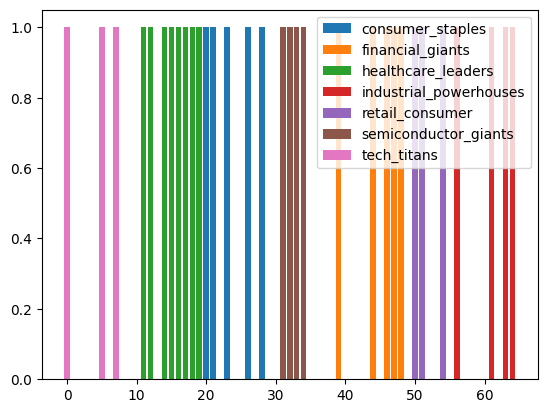

In [164]:
import matplotlib.pyplot as plt
for market,subdf in df_solution.groupby('Market'):
    plt.bar(x=subdf.index, height=subdf.pick, label=market)
plt.legend(loc='best')